<a href="https://colab.research.google.com/github/priyadarshanitamanna-a11y/AI-LAB-PROGRAM-1/blob/main/LAB_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install matplotlib

Problem 1: BFS and DFS Traversal of a Graph:
Problem Statement:
A small graph, shaped like a tree with six nodes (A, B, C, D, E, F) and node A as the root, is given below. Write a Python program that:
1. Stores the graph using an adjacency list (a Python dictionary).
2. Performs a BFS traversal starting from node A.
3. Performs a DFS traversal starting from node A.
4. Prints both traversal orders, and draws two separate tree diagrams — one showing the order in which BFS visits the nodes, and another showing the order in which DFS visits the nodes.


BFS Traversal: A -> B -> C -> D -> E -> F
DFS Traversal: A -> B -> D -> E -> C -> F


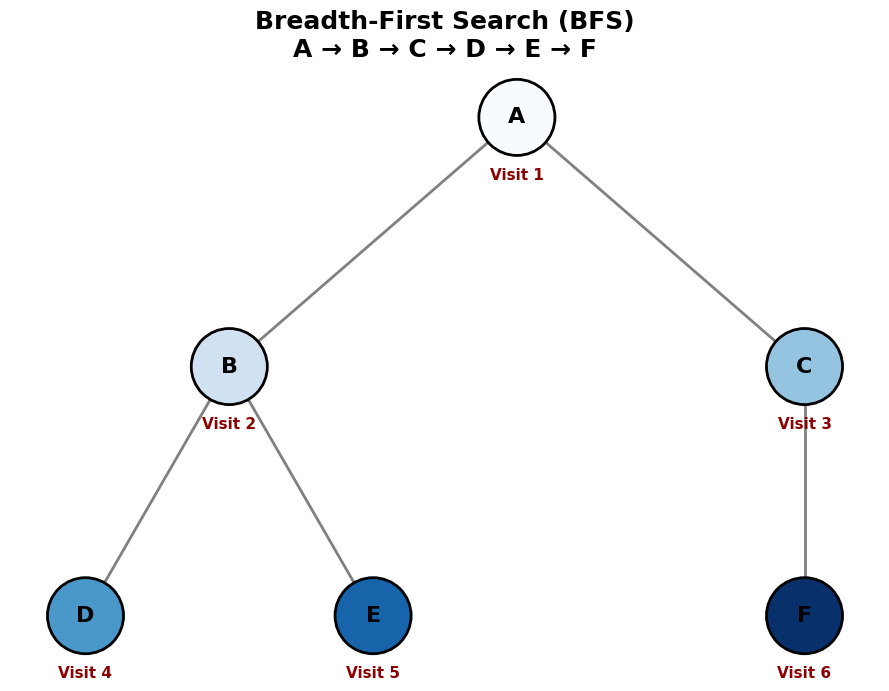

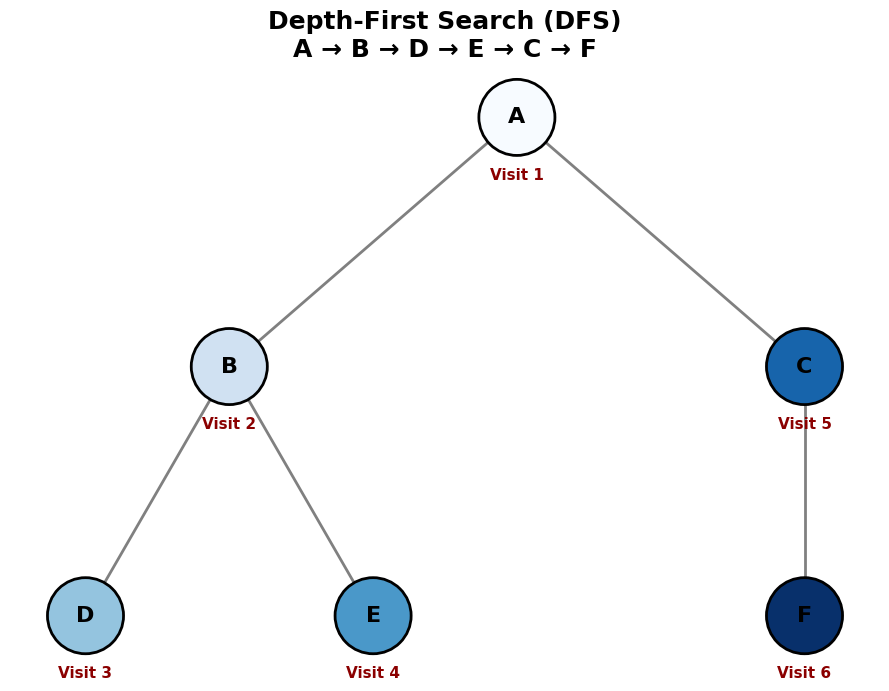

In [8]:
import matplotlib.pyplot as plt
import networkx as nx
from collections import deque

# --------------------------------------------------
# 1. Graph represented using an Adjacency List
# --------------------------------------------------
graph = {
    'A': ['B', 'C'],
    'B': ['D', 'E'],
    'C': ['F'],
    'D': [],
    'E': [],
    'F': []
}


# --------------------------------------------------
# 2. Breadth-First Search (BFS)
# --------------------------------------------------
def bfs(graph, start):
    visited = []
    queue = deque([start])

    while queue:
        node = queue.popleft()

        if node not in visited:
            visited.append(node)
            queue.extend(graph[node])

    return visited


# --------------------------------------------------
# 3. Depth-First Search (DFS)
# --------------------------------------------------
def dfs(graph, start, visited=None):
    if visited is None:
        visited = []

    visited.append(start)

    for node in graph[start]:
        if node not in visited:
            dfs(graph, node, visited)

    return visited


# --------------------------------------------------
# 4. Get BFS and DFS Traversal Orders
# --------------------------------------------------
bfs_order = bfs(graph, 'A')
dfs_order = dfs(graph, 'A')

print("BFS Traversal:", " -> ".join(bfs_order))
print("DFS Traversal:", " -> ".join(dfs_order))


# --------------------------------------------------
# 5. Function to Draw Traversal Diagram
# --------------------------------------------------
def draw_tree(order, title, filename):
    G = nx.DiGraph()

    # Tree structure
    edges = [
        ('A', 'B'),
        ('A', 'C'),
        ('B', 'D'),
        ('B', 'E'),
        ('C', 'F')
    ]

    G.add_edges_from(edges)

    # Fixed positions for a tree-like layout
    pos = {
        'A': (0, 2),
        'B': (-1, 1),
        'C': (1, 1),
        'D': (-1.5, 0),
        'E': (-0.5, 0),
        'F': (1, 0)
    }

    # Create a mapping of node -> visit number
    visit_number = {
        node: i + 1
        for i, node in enumerate(order)
    }

    # Colors based on visit order
    colors = []

    for node in G.nodes():
        colors.append(visit_number[node])

    plt.figure(figsize=(9, 7))

    # Draw edges
    nx.draw_networkx_edges(
        G,
        pos,
        edge_color='gray',
        width=2,
        arrows=False
    )

    # Draw nodes
    nx.draw_networkx_nodes(
        G,
        pos,
        node_color=colors,
        cmap=plt.cm.Blues,
        node_size=3000,
        edgecolors='black',
        linewidths=2
    )

    # Draw node labels
    nx.draw_networkx_labels(
        G,
        pos,
        font_size=16,
        font_weight='bold'
    )

    # Display visit number inside/under each node
    for node, (x, y) in pos.items():
        plt.text(
            x,
            y - 0.25,
            f"Visit {visit_number[node]}",
            ha='center',
            fontsize=11,
            fontweight='bold',
            color='darkred'
        )

    plt.title(
        title,
        fontsize=18,
        fontweight='bold'
    )

    plt.axis('off')
    plt.tight_layout()

    # Save diagram
    plt.savefig(
        filename,
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()


# --------------------------------------------------
# 6. Draw BFS Traversal Diagram
# --------------------------------------------------
draw_tree(
    bfs_order,
    "Breadth-First Search (BFS)\nA → B → C → D → E → F",
    "BFS_Traversal.png"
)


# --------------------------------------------------
# 7. Draw DFS Traversal Diagram
# --------------------------------------------------
draw_tree(
    dfs_order,
    "Depth-First Search (DFS)\nA → B → D → E → C → F",
    "DFS_Traversal.png"
)